# Random Forest — Strategy B: Random Undersampling

A Random Forest classifier is trained using random undersampling to address class imbalance between diabetic and non-diabetic participants. Undersampling reduces the majority class by randomly removing non-diabetes samples from each training fold, so that the classifier sees a balanced training set without generating synthetic data.

This notebook is the direct counterpart of `random_forest_A.ipynb` (SMOTE oversampling), allowing a controlled comparison of how the preprocessing strategy affects predictive performance and feature importance rankings (RQ3).

Hyperparameter tuning is performed using `RandomizedSearchCV` with 10-fold stratified cross-validation. The trained model is saved to disk after the first run so that subsequent runs load the fitted model directly, avoiding the cost of rerunning tuning and cross-validation.

Feature importance is assessed using three methods:
- **SHAP** (TreeExplainer): model-agnostic, interaction-aware
- **Permutation Importance**: model-agnostic, based on test set ROC AUC drop
- **Built-in Mean Decrease in Impurity**: model-specific, averaged across all trees


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

from sklearn.ensemble import RandomForestClassifier
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, roc_auc_score, classification_report,
    precision_score, recall_score, f1_score
)


## Loading the Preprocessed Dataset

The preprocessed training and test sets are loaded from Parquet files produced by `03_preprocessing.ipynb`. These datasets have already been imputed, encoded, and scaled. No further preprocessing is applied here.

In [2]:
X_train_final = pd.read_parquet("../../data/processed/X_train_final.parquet")
X_test_final  = pd.read_parquet("../../data/processed/X_test_final.parquet")
y_train = pd.read_parquet("../../data/processed/y_train.parquet")["diabetes"]
y_test  = pd.read_parquet("../../data/processed/y_test.parquet")["diabetes"]

print("Train shape:", X_train_final.shape)
print("Test shape: ", X_test_final.shape)


Train shape: (20800, 36)
Test shape:  (5201, 36)


## Hyperparameter Tuning with Cross-Validation

`RandomizedSearchCV` with 10-fold stratified cross-validation is used to find the best hyperparameters. The search optimizes for ROC AUC, which is appropriate given the class imbalance in the dataset. The undersampler is included inside the pipeline so that majority-class removal only occurs within each training fold, preventing data leakage into the validation fold.

The fitted model is saved to `models/random_forest_B.pkl` after the first run. On subsequent runs the saved model is loaded directly, skipping tuning entirely. To retune from scratch, delete the `.pkl` file and rerun this cell.

In [3]:
MODEL_PATH = "../../models/random_forest_B.pkl"
os.makedirs("../../models", exist_ok=True)

if os.path.exists(MODEL_PATH):
    best_model = joblib.load(MODEL_PATH)
    print("[OK] Model loaded from disk.")
else:
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    pipeline = Pipeline([
        ("undersampling", RandomUnderSampler(random_state=42)),
        ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
    ])

    param_grid = {
        "model__n_estimators":     [100, 200, 300, 500],
        "model__max_depth":         [None, 5, 10, 15, 20],
        "model__min_samples_split": [2, 5, 10, 20],
        "model__min_samples_leaf":  [1, 2, 5, 10],
        "model__max_features":      ["sqrt", "log2", 0.3, 0.5],
        "model__bootstrap":         [True, False]
    }

    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grid,
        n_iter=40,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        random_state=42
    )

    random_search.fit(X_train_final, y_train)
    best_model = random_search.best_estimator_

    print("Best parameters:", random_search.best_params_)
    print("Best CV ROC AUC:", random_search.best_score_)

    joblib.dump(best_model, MODEL_PATH)
    print("[OK] Model saved to", MODEL_PATH)


Fitting 10 folds for each of 40 candidates, totalling 400 fits
Best parameters: {'model__n_estimators': 500, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 'log2', 'model__max_depth': 15, 'model__bootstrap': True}
Best CV ROC AUC: 0.8259075916015048
[OK] Model saved to ../../models/random_forest_B.pkl


## Final Test Set Evaluation

The best model is evaluated on the held-out test set. The test set is never resampled and preserves the original class distribution, so that evaluation reflects real-world performance.

Performance is measured using accuracy, precision, recall, F1-score, ROC AUC, and the confusion matrix.

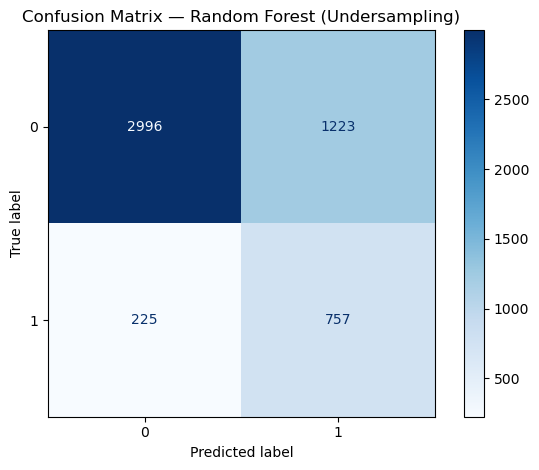

Accuracy: 0.7216
ROC AUC:  0.8202

Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.71      0.81      4219
         1.0       0.38      0.77      0.51       982

    accuracy                           0.72      5201
   macro avg       0.66      0.74      0.66      5201
weighted avg       0.83      0.72      0.75      5201



In [4]:
predictions        = best_model.predict(X_test_final)
pred_probabilities = best_model.predict_proba(X_test_final)[:, 1]

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Random Forest (Undersampling)")
plt.tight_layout()
plt.show()

accuracy = accuracy_score(y_test, predictions)
roc_auc  = roc_auc_score(y_test, pred_probabilities)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC:  {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))


## Exporting Model Performance Metrics

Evaluation metrics are exported to a CSV file in `results/performance/`. This allows the comparison notebook to load results from all models without retraining.

In [5]:
os.makedirs("../../results/performance", exist_ok=True)

metrics = {
    "Model":     "Random Forest",
    "Strategy":  "Undersampling",
    "Accuracy":  accuracy_score(y_test, predictions),
    "Precision": precision_score(y_test, predictions),
    "Recall":    recall_score(y_test, predictions),
    "F1-score":  f1_score(y_test, predictions),
    "ROC AUC":   roc_auc_score(y_test, pred_probabilities),
}

pd.DataFrame([metrics]).to_csv(
    "../../results/performance/random_forest_B_metrics.csv",
    index=False
)
print("[OK] Performance metrics saved.")


[OK] Performance metrics saved.


## Feature Importance — SHAP (TreeExplainer)

`shap.TreeExplainer` computes exact Shapley values for tree-based models. For each test observation, SHAP assigns a contribution value to every feature, indicating how much that feature pushed the prediction above or below the base rate. The mean absolute SHAP value across all test observations is used as the overall importance score.

SHAP values are computed on the full test set (not a subsample) for accurate and reproducible rankings. The full ranking across all features is exported so it can be compared against other methods in the comparison notebook.

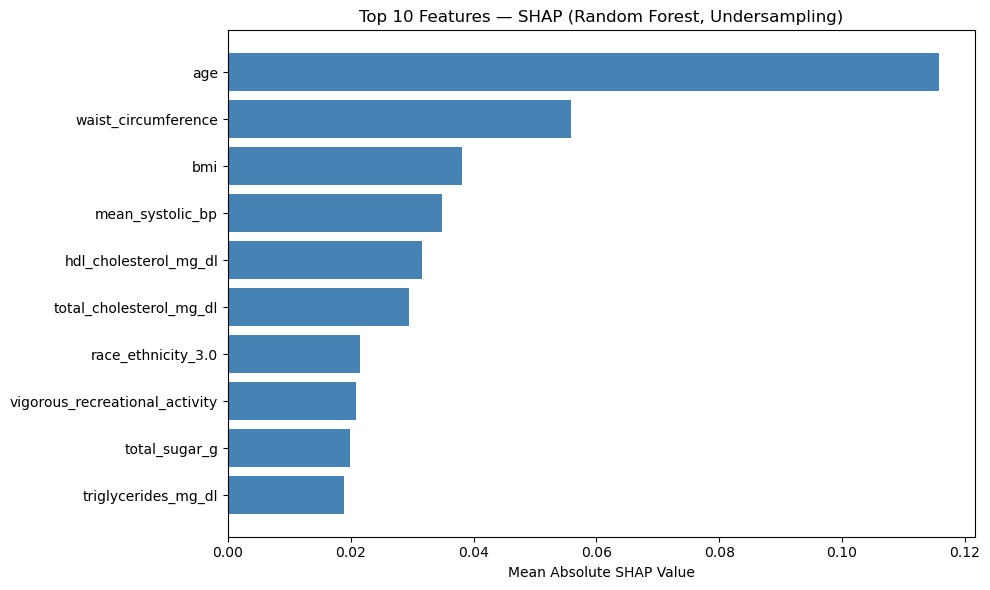

In [6]:
rf_model = best_model.named_steps["model"]

explainer   = shap.TreeExplainer(rf_model)
shap_output = explainer.shap_values(X_test_final, check_additivity=False)

if isinstance(shap_output, list):
    shap_values = shap_output[1]
elif len(shap_output.shape) == 3:
    shap_values = shap_output[:, :, 1]
else:
    shap_values = shap_output

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    "Feature":    X_test_final.columns,
    "Importance": mean_abs_shap
}).sort_values("Importance", ascending=False).reset_index(drop=True)

shap_df["Rank"]     = range(1, len(shap_df) + 1)
shap_df["Model"]    = "Random Forest"
shap_df["Strategy"] = "Undersampling"
shap_df["Method"]   = "SHAP"

top10 = shap_df.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top10["Feature"][::-1], top10["Importance"][::-1], color="steelblue")
plt.xlabel("Mean Absolute SHAP Value")
plt.title("Top 10 Features — SHAP (Random Forest, Undersampling)")
plt.tight_layout()
plt.show()


## Feature Importance — Permutation Importance

Permutation importance measures how much the model's ROC AUC drops when the values of a single feature are randomly shuffled. A large drop indicates that the model relies heavily on that feature; a small or negative drop suggests the feature contributes little.

Permutation importance is computed on the full pipeline (the undersampler is skipped at predict time) using the full held-out test set. `n_repeats=20` shuffles each feature 20 times to reduce variance in the estimate. The full ranking across all features is exported for comparison.

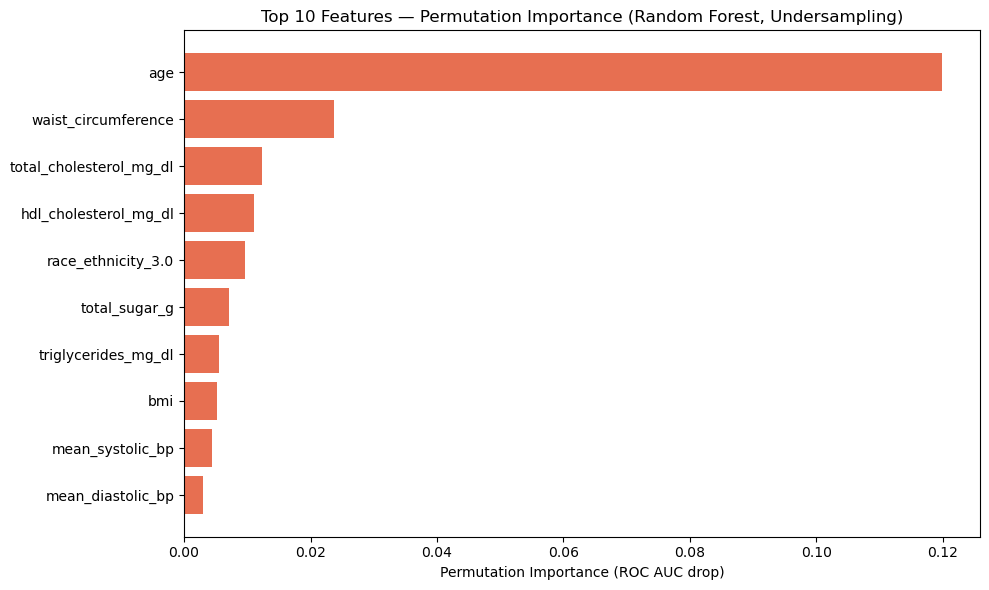

In [7]:
perm_result = permutation_importance(
    best_model,
    X_test_final,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature":        X_test_final.columns,
    "Importance":     perm_result.importances_mean,
    "Importance Std": perm_result.importances_std
}).sort_values("Importance", ascending=False).reset_index(drop=True)

perm_df["Rank"]     = range(1, len(perm_df) + 1)
perm_df["Model"]    = "Random Forest"
perm_df["Strategy"] = "Undersampling"
perm_df["Method"]   = "Permutation"

top10 = perm_df.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top10["Feature"][::-1], top10["Importance"][::-1], color="#e76f51")
plt.xlabel("Permutation Importance (ROC AUC drop)")
plt.title("Top 10 Features — Permutation Importance (Random Forest, Undersampling)")
plt.tight_layout()
plt.show()


## Feature Importance — Built-in Mean Decrease in Impurity

Random Forest provides a model-specific importance score based on the average reduction in Gini impurity per feature across all trees in the forest. Averaging over many trees makes this measure more stable than the single-tree equivalent, but it can still be biased towards high-cardinality and continuous features.

The full ranking across all features is exported for comparison.

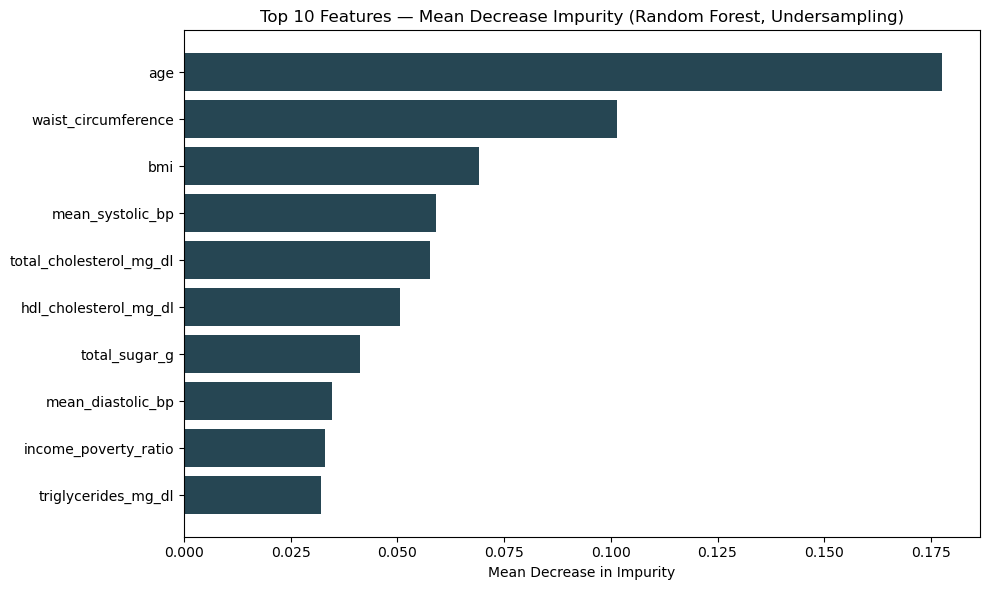

In [8]:
rf_model = best_model.named_steps["model"]

builtin_df = pd.DataFrame({
    "Feature":    X_test_final.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

builtin_df["Rank"]     = range(1, len(builtin_df) + 1)
builtin_df["Model"]    = "Random Forest"
builtin_df["Strategy"] = "Undersampling"
builtin_df["Method"]   = "Mean Decrease Impurity"

top10 = builtin_df.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top10["Feature"][::-1], top10["Importance"][::-1], color="#264653")
plt.xlabel("Mean Decrease in Impurity")
plt.title("Top 10 Features — Mean Decrease Impurity (Random Forest, Undersampling)")
plt.tight_layout()
plt.show()


## Exporting Feature Importance Rankings

All three importance rankings are combined into a single CSV file in `results/features/`. Each row represents one feature under one method, with its importance score and rank. The full ranking (not just top 10) is saved so that Spearman rank correlations can be computed across all features in the comparison notebook.

In [9]:
os.makedirs("../../results/features", exist_ok=True)

cols = ["Model", "Strategy", "Method", "Rank", "Feature", "Importance"]

feature_importance_all = pd.concat([
    shap_df[cols],
    perm_df[cols],
    builtin_df[cols]
], ignore_index=True)

feature_importance_all.to_csv(
    "../../results/features/random_forest_B_feature_importance.csv",
    index=False
)
print("[OK] Feature importance rankings saved.")
display(feature_importance_all.head(15))


[OK] Feature importance rankings saved.


,Model,Strategy,Method,Rank,Feature,Importance
0,Random Forest,Undersampling,SHAP,1,age,0.115815
1,Random Forest,Undersampling,SHAP,2,waist_circumference,0.055831
2,Random Forest,Undersampling,SHAP,3,bmi,0.038033
3,Random Forest,Undersampling,SHAP,4,mean_systolic_bp,0.034902
4,Random Forest,Undersampling,SHAP,5,hdl_cholesterol_mg_dl,0.031665
5,Random Forest,Undersampling,SHAP,6,total_cholesterol_mg_dl,0.029491
6,Random Forest,Undersampling,SHAP,7,race_ethnicity_3.0,0.021559
7,Random Forest,Undersampling,SHAP,8,vigorous_recreational_activity,0.020915
8,Random Forest,Undersampling,SHAP,9,total_sugar_g,0.019922
9,Random Forest,Undersampling,SHAP,10,triglycerides_mg_dl,0.018905
